# BestModel v2 — DeBERTa-v3-base + Adaptive LR

## 0 · Check GPU

In [1]:
import torch
device = (
    torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
)
print(f"Device : {device}")
if device.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## 1 · Install Dependencies

In [2]:
!pip install transformers==4.37.2 datasets scikit-learn sentencepiece protobuf -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 85.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.2.3 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.37.2 which is incompatible.


## 2 · Download Dataset


In [3]:
import urllib.request, os

BASE_HF = "https://huggingface.co/datasets/carlaperez/dont_patronize_me/resolve/main"
BASE_GH = "https://raw.githubusercontent.com/Perez-AlmendrosC/dontpatronizeme/master/semeval-2022/practice%20splits"
BASE_TST = "https://raw.githubusercontent.com/Perez-AlmendrosC/dontpatronizeme/master/semeval-2022/TEST"

files = {
    "dontpatronizeme_pcl.tsv": f"{BASE_HF}/dontpatronizeme_pcl.tsv",
    "train_semeval_parids-labels.csv": f"{BASE_GH}/train_semeval_parids-labels.csv",
    "dev_semeval_parids-labels.csv": f"{BASE_GH}/dev_semeval_parids-labels.csv",
    "task4_test.tsv": f"{BASE_TST}/task4_test.tsv",
}

for fname, url in files.items():
    if not os.path.exists(fname):
        print(f"Downloading {fname}...")
        urllib.request.urlretrieve(url, fname)
    print(f"  {fname}  ({os.path.getsize(fname)/1e3:.0f} KB)")

  dontpatronizeme_pcl.tsv  (3122 KB)
  train_semeval_parids-labels.csv  (242 KB)
  dev_semeval_parids-labels.csv  (61 KB)
  task4_test.tsv  (1145 KB)


## 3 · Load & Inspect Data

In [16]:
import pandas as pd
import numpy as np

def load_pcl(tsv_path, id_csv=None):
    rows = []
    with open(tsv_path, encoding="utf-8") as f:
        for line in f.readlines()[0:]:
            parts = line.strip().split("\t")
            if len(parts) >= 6:
                rows.append({"par_id": parts[0], "text": parts[4], "orig_label": parts[-1]})
    df = pd.DataFrame(rows)
    df["label"] = df["orig_label"].apply(lambda x: 0 if x in ["0","1"] else 1)
    if id_csv:
        ids = pd.read_csv(id_csv, header=None, names=["par_id","label"])
        ids["par_id"] = ids["par_id"].astype(str)
        df["par_id"] = df["par_id"].astype(str)
        df = df[df["par_id"].isin(ids["par_id"])].reset_index(drop=True)
    return df

def load_test(tsv_path):
    rows = []
    with open(tsv_path, encoding="utf-8") as f:
        for line in f.readlines()[0:]:
            parts = line.strip().split("\t")
            if len(parts) >= 5:
                rows.append({"par_id": parts[0], "text": parts[4]})
    return pd.DataFrame(rows)

train_df = load_pcl("dontpatronizeme_pcl.tsv", "train_semeval_parids-labels.csv")
dev_df = load_pcl("dontpatronizeme_pcl.tsv", "dev_semeval_parids-labels.csv")
test_df = load_test("task4_test.tsv")

print(f"Train : {len(train_df):,}  (PCL={train_df['label'].sum():,}, "f"{train_df['label'].mean()*100:.1f}%)")
print(f"Dev   : {len(dev_df):,}  (PCL={dev_df['label'].sum():,}, "f"{dev_df['label'].mean()*100:.1f}%)")
print(f"Test  : {len(test_df):,}  (no labels)")

# Class weights with 0.7 scale — softer than full balanced formula
N = len(train_df)
N0 = (train_df["label"] == 0).sum()
N1 = (train_df["label"] == 1).sum()
WEIGHT_SCALE = 0.7
W_NEG = round(N / (2 * N0) * WEIGHT_SCALE, 3)
W_POS = round(N / (2 * N1) * WEIGHT_SCALE, 3)
print(f"\nClass weights (scale={WEIGHT_SCALE})  →  w(No-PCL)={W_NEG},  w(PCL)={W_POS}")
print(f"Imbalance ratio: {N0/N1:.1f}:1")

Train : 8,375  (PCL=794, 9.5%)
Dev   : 2,094  (PCL=199, 9.5%)
Test  : 3,832  (no labels)

Class weights (scale=0.7)  →  w(No-PCL)=0.387,  w(PCL)=3.692
Imbalance ratio: 9.5:1


## 4 · Dataset & Config

In [5]:
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

MODEL_NAME = "microsoft/deberta-v3-base"
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 10
LR = 1e-5
WARMUP_FRAC = 0.15
PATIENCE = 3
LR_FACTOR = 0.5
LR_PATIENCE = 1
MIN_LR = 1e-7

print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class PCLDataset(Dataset):
    """Lazy tokenisation — one sample at a time in __getitem__."""
    def __init__(self, texts, labels=None):
        self.texts  = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(self.texts[idx], truncation=True, padding="max_length", max_length=MAX_LEN, return_tensors="pt")
        item = {k: v.squeeze(0) for k, v in enc.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_ds = PCLDataset(train_df["text"].tolist(), train_df["label"].tolist())
dev_ds = PCLDataset(dev_df["text"].tolist(), dev_df["label"].tolist())
test_ds = PCLDataset(test_df["text"].tolist())

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
dev_loader = DataLoader(dev_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches : {len(train_loader)}  |  Dev batches: {len(dev_loader)}  |  Test batches: {len(test_loader)}")

Loading tokenizer: microsoft/deberta-v3-base


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:515: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Train batches : 524  |  Dev batches: 131  |  Test batches: 240


## 5 · Model, Loss & Optimiser

In [7]:
import torch
from torch import nn
from transformers import AutoModelForSequenceClassification
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import f1_score, classification_report
import random, json

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if device.type == "cuda": torch.cuda.manual_seed_all(SEED)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.to(device)

class_weights = torch.tensor([W_NEG, W_POS], dtype=torch.float).to(device)
loss_fn = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

total_steps = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_FRAC)
global_step = 0

optimiser = AdamW(model.parameters(), lr=0.0, weight_decay=0.01)

plateau_scheduler = ReduceLROnPlateau(optimiser, mode="max", factor=LR_FACTOR, patience=LR_PATIENCE, min_lr=MIN_LR,)

print(f"Model params   : {sum(p.numel() for p in model.parameters())/1e6:.1f}M")
print(f"Warmup steps   : {warmup_steps} / {total_steps} total  ({WARMUP_FRAC:.0%})")
print(f"Loss fn        : CrossEntropyLoss(weights={[W_NEG,W_POS]}, label_smoothing=0.1)")
print(f"LR schedule    : Manual linear warmup → ReduceLROnPlateau(factor={LR_FACTOR}, patience={LR_PATIENCE})")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model params   : 184.4M
Warmup steps   : 786 / 5240 total  (15%)
Loss fn        : CrossEntropyLoss(weights=[np.float64(0.387), np.float64(3.692)], label_smoothing=0.1)
LR schedule    : Manual linear warmup → ReduceLROnPlateau(factor=0.5, patience=1)


## 6 · Training & Evaluation Functions

In [9]:
def train_epoch(model, loader, optimiser, loss_fn, device):
    """One training epoch with manual linear warmup baked in."""
    global global_step
    model.train()
    total_loss = 0
    for batch in loader:
        optimiser.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimiser.step()

        global_step += 1
        if global_step <= warmup_steps:
            new_lr = LR * global_step / warmup_steps
            for pg in optimiser.param_groups:
                pg['lr'] = new_lr
        total_loss += loss.item()

    return total_loss / len(loader)

def evaluate(model, loader, device, threshold=0.5):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"]
            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
            probs = torch.softmax(logits, dim=-1)[:,1].cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())
    preds = (np.array(all_probs) >= threshold).astype(int)
    f1 = f1_score(all_labels, preds, pos_label=1, zero_division=0)

    return f1, np.array(all_probs), np.array(all_labels)

def get_test_probs(model, loader, device):
    model.eval()
    all_probs = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
            probs = torch.softmax(logits, dim=-1)[:,1].cpu().numpy()
            all_probs.extend(probs)

    return np.array(all_probs)

## 7 · Train with Early Stopping + Adaptive LR

In [10]:
import time

print("  Training: DeBERTa-v3-base + ReduceLROnPlateau")

best_f1, best_epoch, patience_ctr = 0.0, 0, 0
best_state = None
history = []

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_loss = train_epoch(model, train_loader, optimiser, loss_fn, device)
    dev_f1, _, _ = evaluate(model, dev_loader, device, threshold=0.5)
    elapsed = time.time() - t0
    current_lr = optimiser.param_groups[0]["lr"]

    prev_lr = current_lr
    plateau_scheduler.step(dev_f1)
    current_lr = optimiser.param_groups[0]["lr"]
    lr_tag = f"  ↓ LR {prev_lr:.2e}→{current_lr:.2e}" if current_lr < prev_lr else ""

    history.append({"epoch": epoch, "train_loss": round(train_loss, 4), "dev_f1_t05": round(dev_f1, 4), "lr": current_lr})

    print(f"Epoch {epoch}/{EPOCHS}  loss={train_loss:.4f}  "
          f"dev_F1(t=0.5)={dev_f1:.4f}  lr={current_lr:.2e}  [{elapsed:.0f}s]", end="")

    if dev_f1 > best_f1:
        best_f1, best_epoch = dev_f1, epoch
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_ctr = 0
        print("  ← best ✓")
    else:
        patience_ctr += 1
        print(f"  (patience {patience_ctr}/{PATIENCE}){lr_tag}")
        if patience_ctr >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break

print(f"\nBest  dev F1 (t=0.5) : {best_f1:.4f}  (epoch {best_epoch})")

model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
print("Best checkpoint restored.")

  Training: DeBERTa-v3-base + ReduceLROnPlateau
Epoch 1/10  loss=0.8201  dev_F1(t=0.5)=0.2629  lr=6.67e-06  [278s]  ← best ✓
Epoch 2/10  loss=0.7452  dev_F1(t=0.5)=0.5627  lr=1.00e-05  [276s]  ← best ✓
Epoch 3/10  loss=0.6905  dev_F1(t=0.5)=0.5753  lr=1.00e-05  [276s]  ← best ✓
Epoch 4/10  loss=0.6458  dev_F1(t=0.5)=0.5603  lr=1.00e-05  [276s]  (patience 1/3)
Epoch 5/10  loss=0.6081  dev_F1(t=0.5)=0.5979  lr=1.00e-05  [276s]  ← best ✓
Epoch 6/10  loss=0.5762  dev_F1(t=0.5)=0.5882  lr=1.00e-05  [276s]  (patience 1/3)
Epoch 7/10  loss=0.5631  dev_F1(t=0.5)=0.5630  lr=5.00e-06  [276s]  (patience 2/3)  ↓ LR 1.00e-05→5.00e-06
Epoch 8/10  loss=0.5541  dev_F1(t=0.5)=0.5604  lr=5.00e-06  [276s]  (patience 3/3)
Early stopping at epoch 8.

Best  dev F1 (t=0.5) : 0.5979  (epoch 5)
Best checkpoint restored.


## 8 · Threshold Optimisation on Dev Set

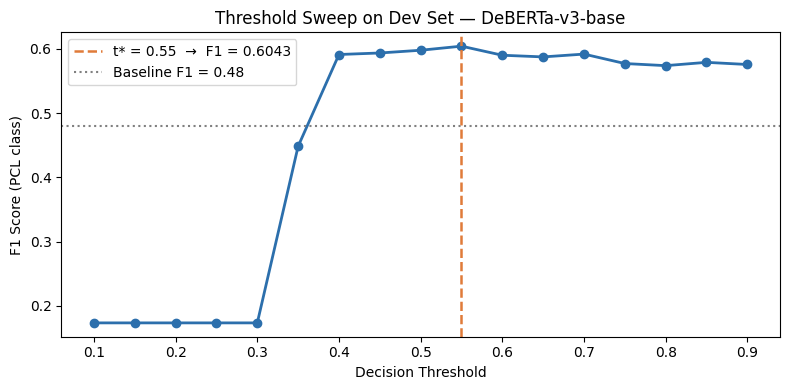

Optimal threshold  t* = 0.55
Dev F1 @ t=0.50 = 0.5979
Dev F1 @ t*=0.55 = 0.6043
Improvement over baseline (0.48) = +0.1243

Threshold sweep detail:
  t=0.10  F1=0.1736
  t=0.15  F1=0.1736
  t=0.20  F1=0.1736
  t=0.25  F1=0.1736
  t=0.30  F1=0.1736
  t=0.35  F1=0.4484
  t=0.40  F1=0.5913
  t=0.45  F1=0.5937
  t=0.50  F1=0.5979
  t=0.55  F1=0.6043 ← best
  t=0.60  F1=0.5902
  t=0.65  F1=0.5876
  t=0.70  F1=0.5920
  t=0.75  F1=0.5773
  t=0.80  F1=0.5740
  t=0.85  F1=0.5791
  t=0.90  F1=0.5758


In [17]:
import matplotlib.pyplot as plt

_, dev_probs, dev_labels = evaluate(model, dev_loader, device, threshold=0.5)

thresholds = np.arange(0.10, 0.91, 0.05)
sweep_f1 = []
for t in thresholds:
    preds = (dev_probs >= t).astype(int)
    sweep_f1.append(f1_score(dev_labels, preds, pos_label=1, zero_division=0))

best_idx = int(np.argmax(sweep_f1))
best_t = round(float(thresholds[best_idx]), 2)
best_t_f1 = round(sweep_f1[best_idx], 4)

plt.figure(figsize=(8, 4))
plt.plot(thresholds, sweep_f1, marker='o', color='#2C6FAC', linewidth=2)
plt.axvline(best_t, color='#E07B39', linestyle='--', linewidth=1.8, label=f't* = {best_t}  →  F1 = {best_t_f1:.4f}')
plt.axhline(0.48, color='grey', linestyle=':', linewidth=1.5, label='Baseline F1 = 0.48')
plt.xlabel('Decision Threshold')
plt.ylabel('F1 Score (PCL class)')
plt.title('Threshold Sweep on Dev Set — DeBERTa-v3-base')
plt.legend(); plt.tight_layout()
plt.savefig('threshold_sweep.png', dpi=150)
plt.show()

print(f"Optimal threshold  t* = {best_t}")
print(f"Dev F1 @ t=0.50 = {best_f1:.4f}")
print(f"Dev F1 @ t*={best_t} = {best_t_f1:.4f}")
print(f"Improvement over baseline (0.48) = {best_t_f1 - 0.48:+.4f}")

print("\nThreshold sweep detail:")
for t, f in zip(thresholds, sweep_f1):
    marker = " ← best" if round(t, 2) == best_t else ""
    print(f"  t={t:.2f}  F1={f:.4f}{marker}")

## 9 · Final Dev Set Evaluation

In [18]:
dev_preds_final = (dev_probs >= best_t).astype(int)

print(f"Dev set classification report  (threshold t*={best_t})\n")
print(classification_report(dev_labels, dev_preds_final,
                             target_names=["No PCL", "PCL"], digits=4))

Dev set classification report  (threshold t*=0.55)

              precision    recall  f1-score   support

      No PCL     0.9552    0.9673    0.9612      1895
         PCL     0.6457    0.5678    0.6043       199

    accuracy                         0.9293      2094
   macro avg     0.8004    0.7676    0.7827      2094
weighted avg     0.9258    0.9293    0.9273      2094



## 10 · Generate & Save Predictions

In [19]:
# dev.txt
dev_preds_list = dev_preds_final.tolist()
with open("dev.txt", "w") as f:
    f.write("\n".join(str(p) for p in dev_preds_list) + "\n")
print(f"dev.txt  : {len(dev_preds_list):,} lines  (PCL predicted: {sum(dev_preds_list):,})")

# test.txt
test_probs = get_test_probs(model, test_loader, device)
test_preds = (test_probs >= best_t).astype(int).tolist()
with open("test.txt", "w") as f:
    f.write("\n".join(str(p) for p in test_preds) + "\n")
print(f"test.txt : {len(test_preds):,} lines  (PCL predicted: {sum(test_preds):,})")

# results.json
results_meta = {
    "model": MODEL_NAME,
    "max_len": MAX_LEN,
    "batch_size": BATCH_SIZE,
    "lr_initial": LR,
    "warmup_frac": WARMUP_FRAC,
    "patience": PATIENCE,
    "lr_factor": LR_FACTOR,
    "lr_patience": LR_PATIENCE,
    "weight_scale": WEIGHT_SCALE,
    "label_smoothing": 0.1,
    "epochs_trained": best_epoch,
    "class_weights": {"No_PCL": W_NEG, "PCL": W_POS},
    "optimal_threshold": best_t,
    "dev_f1_t050": round(best_f1, 4),
    "dev_f1_tstar": best_t_f1,
    "improvement_over_baseline": round(best_t_f1 - 0.48, 4),
    "training_history": history,
}
with open("results.json", "w") as f:
    json.dump(results_meta, f, indent=2)

print("\nresults.json saved.")

print(f"\n  FINAL dev F1 (t*={best_t}) = {best_t_f1:.4f}")
print(f"  Baseline = 0.4800")
print(f"  Improvement = {best_t_f1 - 0.48:+.4f}")

dev.txt  : 2,094 lines  (PCL predicted: 175)
test.txt : 3,828 lines  (PCL predicted: 288)

results.json saved.

  FINAL dev F1 (t*=0.55) = 0.6043
  Baseline = 0.4800
  Improvement = +0.1243


## 11 · Save Model Weights

In [14]:
import shutil, zipfile

torch.save(model.state_dict(), "best_model.pt")
size_mb = os.path.getsize("best_model.pt") / 1e6
print(f"best_model.pt : {size_mb:.0f} MB")

import json
with open("best_model_meta.json", "w") as f:
    json.dump({"optimal_threshold": best_t, "dev_f1_tstar": best_t_f1,
               "model": MODEL_NAME, "epochs_trained": best_epoch}, f, indent=2)
print("best_model_meta.json saved.")

with zipfile.ZipFile("best_model.zip", "w", zipfile.ZIP_DEFLATED) as zf:
    zf.write("best_model.pt")
    zf.write("best_model_meta.json")
zip_mb = os.path.getsize("best_model.zip") / 1e6
print(f"best_model.zip : {zip_mb:.0f} MB  (best_model.pt + best_model_meta.json)")

best_model.pt : 738 MB
best_model_meta.json saved.
best_model.zip : 597 MB  (best_model.pt + best_model_meta.json)


In [15]:
from google.colab import files

print("Downloading output files...")
for fname in ["best_model.zip"]:
    if os.path.exists(fname):
        files.download(fname)
        size_mb = os.path.getsize(fname) / 1e6
        print(f"  Downloaded: {fname}  ({size_mb:.1f} MB)")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: best_model.zip  (596.9 MB)
